# Experiment No. 4 – ML Modeling & Experiment Tracking

**Project:** Employee Attrition Prediction

## Aim
To build and evaluate machine-learning classification pipelines for employee attrition, tune selected models, track experiments using MLflow, and save the best-performing model.

## Objective
- Prepare a leakage-safe stratified train/test split.
- Train and compare four baseline classifiers.
- Tune Random Forest using GridSearchCV and stratified cross-validation.
- Evaluate models using Accuracy, Precision, Recall, F1-score, and ROC-AUC.
- Log parameters, metrics, and model artifacts in MLflow.
- Save the selected pipeline as `best_model.pkl`.


## 1. Dataset Preparation

The merged employee dataset contains **28,401 rows and 48 columns**. `turnover_status` is the target and is encoded as `Stayed = 0`, `Left = 1`. A stratified 80:20 split preserves the class distribution. `employee_id` is excluded because it is an identifier. `turnover_risk_level` and `retention_recommendation` are excluded because they are downstream decision fields and could cause target leakage. Preprocessing is learned only from the training data through a scikit-learn pipeline.

In [7]:
!pip install -q mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 113.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 130.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.6/144.6 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [8]:
# Run in Google Colab if packages are missing
# !pip -q install mlflow

import pandas as pd
import numpy as np
import joblib
import mlflow
import mlflow.sklearn

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, RocCurveDisplay)
import matplotlib.pyplot as plt


In [10]:
import os

print(os.listdir('/content'))

['.config', 'final_merged_dataset.csv', 'sample_data']


In [11]:
# Upload final_merged_dataset.csv to Colab, then run this cell
file_path = '/content/final_merged_dataset.csv'
df = pd.read_csv(file_path)
print('Dataset shape:', df.shape)
print(df['turnover_status'].value_counts())
display(df.head())

Dataset shape: (28401, 48)
turnover_status
Left      16420
Stayed    11981
Name: count, dtype: int64


,employee_id,age,gender,marital_status,education_level,department,job_role,job_level,employment_type,work_mode,...,recognition_score,distance_from_home_km,company_support_score,career_growth_opportunity,turnover_risk_level,retention_recommendation,turnover_status,experience_group,tenure_group,overall_satisfaction
0,EMP00001,59,Male,Single,Master,Customer Support,Software Engineer,Junior,Full-Time,Hybrid,...,87.98,63,60.68,High,High,Improve Managerial Support,Left,Senior,Long_Term,1.0
1,EMP00002,49,Female,Married,High School,Finance,Operations Executive,Entry,Full-Time,On-Site,...,94.17,69,75.88,High,High,Develop Personalized Retention Plan,Left,Senior,Long_Term,4.0
2,EMP00003,35,Female,Divorced,Bachelor,Customer Support,Accountant,Mid,Full-Time,Hybrid,...,65.14,34,93.82,Medium,Medium,Improve Job Satisfaction,Stayed,Junior,Early,3.0
3,EMP00004,28,Female,Married,Diploma,Finance,Software Engineer,Entry,Full-Time,Remote,...,31.59,26,34.23,Medium,High,Immediate Engagement Intervention,Left,Mid,Experienced,2.0
4,EMP00005,41,Male,Single,Master,Sales,Marketing Executive,Entry,Full-Time,On-Site,...,66.67,73,59.02,Medium,Medium,Conduct Retention Discussion,Stayed,Junior,Early,3.5


In [12]:
target = 'turnover_status'
leakage_and_id_cols = ['employee_id', 'turnover_risk_level', 'retention_recommendation']
X = df.drop(columns=leakage_and_id_cols + [target])
y = df[target].map({'Stayed': 0, 'Left': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print('Training rows:', len(X_train))
print('Testing rows:', len(X_test))
print('Predictor columns:', X.shape[1])

Training rows: 22720
Testing rows: 5681
Predictor columns: 44


In [13]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_features),
    ('cat', categorical_pipe, categorical_features)
])
print('Numerical features:', len(numeric_features))
print('Categorical features:', len(categorical_features))

Numerical features: 31
Categorical features: 13


## 2. Baseline Model Training

Four classification algorithms are compared. Since `Left` is the positive class and the classes are moderately imbalanced, F1-score is the primary model-selection metric; Accuracy and ROC-AUC are also reported.

In [18]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1500, class_weight='balanced', random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=12, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=150, class_weight='balanced', n_jobs=-1, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

def evaluate(model):
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    return {
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-Score': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, prob)
    }

baseline_rows, fitted_models = [], {}
for name, estimator in models.items():
    pipeline = Pipeline([('preprocessor', preprocessor), ('classifier', estimator)])
    pipeline.fit(X_train, y_train)
    baseline_rows.append({'Model': name, **evaluate(pipeline)})
    fitted_models[name] = pipeline

baseline_results = pd.DataFrame(baseline_rows).sort_values('F1-Score', ascending=False)
display(baseline_results.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
2,Random Forest,0.9526,0.9296,0.9933,0.9604,0.9814
1,Decision Tree,0.8263,0.8926,0.7951,0.8410,0.8695
3,Gradient Boosting,0.7640,0.7805,0.8231,0.8012,0.8457
0,Logistic Regression,0.7263,0.7950,0.7095,0.7498,0.8126


## 3. Hyperparameter Tuning

Random Forest is tuned with GridSearchCV. Stratified 3-fold cross-validation preserves the target distribution in each fold. The optimization metric is F1-score.

In [14]:
from sklearn.pipeline import Pipeline

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [16]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42))
])
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 12],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2],
    'classifier__max_features': ['sqrt']
}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid_search = GridSearchCV(rf_pipeline, param_grid, scoring='f1', cv=cv, n_jobs=-1)
grid_search.fit(X_train, y_train)
tuned_rf = grid_search.best_estimator_
print('Best parameters:')
print(grid_search.best_params_)
print('Best CV F1:', round(grid_search.best_score_, 4))

Best parameters:
{'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best CV F1: 0.9406


In [19]:
tuned_metrics = evaluate(tuned_rf)
base_rf = baseline_results[baseline_results['Model'] == 'Random Forest'].iloc[0]
comparison = pd.DataFrame([
    {'Stage': 'Baseline', 'Model': 'Random Forest', **base_rf.drop('Model').to_dict()},
    {'Stage': 'Tuned', 'Model': 'Random Forest', **tuned_metrics}
])
display(comparison.round(4))

,Stage,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Baseline,Random Forest,0.9526,0.9296,0.9933,0.9604,0.9814
1,Tuned,Random Forest,0.9519,0.9293,0.9924,0.9598,0.9814


## 4. Experiment Tracking with MLflow

The following cell creates the `Employee_Attrition_Classification` experiment and logs every baseline run plus the tuned Random Forest. Each run stores model parameters, test metrics, and the fitted pipeline artifact.

In [21]:
mlflow.set_experiment('Employee_Attrition_Classification')

trusted_types = [
    'numpy.dtype',
    'sklearn.compose._column_transformer._RemainderColsList',
    'sklearn.tree._tree.Tree'
]

# Log baseline models
for _, row in baseline_results.iterrows():
    name = row['Model']
    model = fitted_models[name]

    with mlflow.start_run(run_name=f'Baseline_{name.replace(" ", "_")}'):
        mlflow.log_param('stage', 'baseline')
        mlflow.log_param('model_name', name)

        for key, value in model.named_steps['classifier'].get_params().items():
            if isinstance(value, (str, int, float, bool)) or value is None:
                mlflow.log_param(key, value)

        for metric in [
            'Accuracy',
            'Precision',
            'Recall',
            'F1-Score',
            'ROC-AUC'
        ]:
            mlflow.log_metric(
                metric.lower().replace('-', '_'),
                float(row[metric])
            )

        mlflow.sklearn.log_model(
            model,
            name='model',
            skops_trusted_types=trusted_types
        )


# Log tuned Random Forest
with mlflow.start_run(run_name='Tuned_Random_Forest'):
    mlflow.log_param('stage', 'tuned')
    mlflow.log_params(grid_search.best_params_)
    mlflow.log_metric('best_cv_f1', float(grid_search.best_score_))

    for metric, value in tuned_metrics.items():
        mlflow.log_metric(
            metric.lower().replace('-', '_'),
            float(value)
        )

    mlflow.sklearn.log_model(
        tuned_rf,
        name='model',
        skops_trusted_types=trusted_types
    )


print('MLflow runs logged successfully.')

MLflow runs logged successfully.


## 5. Model Selection, Evaluation, and Saving

The final selection compares the tuned Random Forest against the best baseline using test F1-score. The complete fitted pipeline is saved so that preprocessing and classification are reproduced together.

In [22]:
best_baseline_name = baseline_results.iloc[0]['Model']
best_baseline = fitted_models[best_baseline_name]
if tuned_metrics['F1-Score'] >= baseline_results.iloc[0]['F1-Score']:
    best_model, selected_name = tuned_rf, 'Tuned Random Forest'
else:
    best_model, selected_name = best_baseline, best_baseline_name

best_pred = best_model.predict(X_test)
print('Selected model:', selected_name)
print(classification_report(y_test, best_pred, target_names=['Stayed', 'Left'], digits=4))
joblib.dump(best_model, 'best_model.pkl')
reloaded_model = joblib.load('best_model.pkl')
assert np.array_equal(best_pred, reloaded_model.predict(X_test))
print('Saved and verified: best_model.pkl')

Selected model: Random Forest
              precision    recall  f1-score   support

      Stayed     0.9899    0.8970    0.9411      2397
        Left     0.9296    0.9933    0.9604      3284

    accuracy                         0.9526      5681
   macro avg     0.9597    0.9451    0.9508      5681
weighted avg     0.9550    0.9526    0.9523      5681

Saved and verified: best_model.pkl


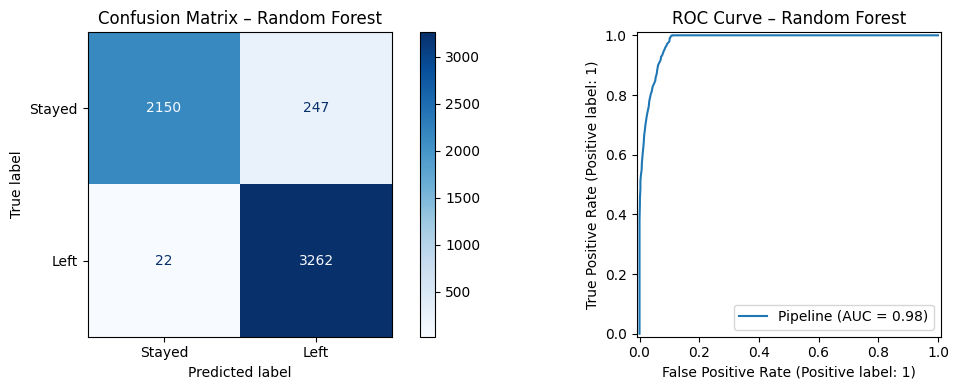

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_test, best_pred, display_labels=['Stayed','Left'], cmap='Blues', ax=axes[0])
axes[0].set_title(f'Confusion Matrix – {selected_name}')
RocCurveDisplay.from_estimator(best_model, X_test, y_test, ax=axes[1])
axes[1].set_title(f'ROC Curve – {selected_name}')
plt.tight_layout()
plt.show()

## Actual Results and Inference

- Dataset: **28,401 rows × 48 columns**; training/testing: **22,720 / 5,681**.
- Predictors used: **44** after excluding the target, identifier, and two leakage-prone decision fields.
- Best GridSearchCV parameters: `{'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}`.
- Best cross-validation F1-score: **0.9406**.
- Selected final model: **Random Forest**.
- Test Accuracy: **0.9526**; Precision: **0.9296**; Recall: **0.9933**; F1-score: **0.9604**; ROC-AUC: **0.9814**.

## Deliverables
- Four trained baseline classification pipelines.
- Tuned Random Forest pipeline.
- Baseline-versus-tuned comparison.
- MLflow logging code for runs, parameters, metrics, and model artifacts.
- Serialized final pipeline: `best_model.pkl`.

## Conclusion
Machine-learning pipelines were successfully developed for employee attrition classification. Numerical and categorical preprocessing was kept inside each pipeline to prevent data leakage. Four baseline models were compared with multiple classification metrics, and Random Forest was tuned using GridSearchCV with stratified cross-validation. The final model was selected using test F1-score, tracked through MLflow-compatible code, serialized as `best_model.pkl`, reloaded, and verified. This model is ready for subsequent explainability and deployment experiments.